Part 1:
- There are 86 observations in the data set.
- There are 11 variables.
- Each row represents one student's response to the survey
- Each column contains all students' answers to one of the questions.
- The numerical variables are proficiency with github and proficiency with Python. 
- The categorial variables are undergraduate major, type of phone, SQL use, favorite sport, favorite season, undergraduate degree date, hours of sleep, ideal outdoor temperature, and visited U.S. states.
- Undergraduate major, hours of sleep, favorite sport, temperature, and favorite sport all contain free-form text.  
- Hours of sleep, ideal temperature, and visited U.S. states are all stored as strings that actually represent integers.
- Yes, the favorite sport category has multiple missing values and there is a missing value in the phone type category.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("DS6021_F26_Class Data.csv")

data_dict = pd.DataFrame({'Variable': ['timestamp', 
    'undergrad_major', 'phone_type', 'undergrad_years', 'sleep_hours',
    'git_proficiency', 'python_proficiency', 'SQL', 'fav_sport', 
    'fave_temp', 'visited_states', 'fav_season'],
    'Description': ['Time submitted (EST)', 
    'Undergraduate major', 'Phone type', 'Years since undergraduate degree',
     'Hours of sleep per night',
    'Proficiency in Git/GitHub', 'Proficiency in Python', 'Experience in SQL', 
    'Favorite sport to watch on TV', 
    'Favorite outside temperature', 
    'Number of U.S. states visited', 'Favorite season'],
    'Original Type': list(df.dtypes),
    'Desired Type': ['datetime', 'str', 'str', 'str', 'int64', 'int64', 'int64', 'str',
    'str', 'int64', 'int64', 'str']
})
print(df)

          timestamp         undergrad_major phone_type undergrad_years  \
0    8/25/2026 8:20              Psychology     iPhone       4-6 years   
1    8/25/2026 9:35              Statistics     iPhone       1-3 years   
2   8/25/2026 13:43               Economics     iPhone        < 1 year   
3   8/25/2026 15:11            Data Science     iPhone        < 1 year   
4   8/25/2026 15:26             Mathematics     iPhone       1-3 years   
..              ...                     ...        ...             ...   
81  8/26/2026 11:42          Bioinformatics     iPhone        < 1 year   
82  8/26/2026 11:44        Computer Science     iPhone        < 1 year   
83  8/26/2026 11:48  Information Technology     iPhone       1-3 years   
84  8/26/2026 11:52            Data Science     iPhone        < 1 year   
85  8/26/2026 12:16                 English    Android       10+ years   

    sleep_hours  git_proficiency  python_proficiency  SQL       fav_sport  \
0             8                3  

Part 2

In [2]:
#help(pd.to_datetime)
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst = False)
df.dtypes

timestamp             datetime64[us]
undergrad_major                  str
phone_type                       str
undergrad_years                  str
sleep_hours                    int64
git_proficiency                int64
python_proficiency             int64
SQL                              str
fav_sport                        str
fav_temp                       int64
visit_states                   int64
fav_season                       str
dtype: object

In [3]:
changes_dict = pd.DataFrame({'Variable': ['undergrad_major','sleep_time', 'fav_sport', 'fav_temp', 'visited_states', 'Missing data'],
                             'Issue': ['Double majors, concentrations', 'Range of hours, non-integers', 'College vs. Professional, non-sports watchers', 
                                       'Range of temperatures, non-integers', 'Range of states, vague answers', 'Full name instead of undergrad major, blank cell'],
                            'Transformation': ['Double major: used first major listed, Concentrations/Specific majors: If no data about the major was found online it was assumed to be a concentration and merged into "main" major',
                                               'Rounded to closest integer, used average and rounded for ranges', 'Combined college and professional versions of the same sport, non-sports watchers are labeled as NA',
                                               'Rounded to closest integer, used average and rounded for ranges', 'Averaged ranges and rounded to closest integer, any guesses were taken at face value. "No clue" answer was changed to 30',
                                               'Changed full name in undergraduate major section and blank cell in phone type section to "N/A"'
                                               ]


    
})

print(changes_dict)

          Variable                                             Issue  \
0  undergrad_major                     Double majors, concentrations   
1       sleep_time                      Range of hours, non-integers   
2        fav_sport     College vs. Professional, non-sports watchers   
3         fav_temp               Range of temperatures, non-integers   
4   visited_states                    Range of states, vague answers   
5     Missing data  Full name instead of undergrad major, blank cell   

                                      Transformation  
0  Double major: used first major listed, Concent...  
1  Rounded to closest integer, used average and r...  
2  Combined college and professional versions of ...  
3  Rounded to closest integer, used average and r...  
4  Averaged ranges and rounded to closest integer...  
5  Changed full name in undergraduate major secti...  


Part 3

In [4]:
sleep_counts = (df['sleep_hours'].value_counts())
print(sleep_counts)
print(float(df['sleep_hours'].mean()))
print(float(df['sleep_hours'].std()))
print(df['sleep_hours'].median())
print(df['sleep_hours'].min())
print(df['sleep_hours'].max())
print(df['sleep_hours'].quantile(.25))
print(df['sleep_hours'].quantile(.5))
print(df['sleep_hours'].quantile(.75))

sleep_hours
7     36
8     27
9      9
6      8
5      3
10     2
4      1
Name: count, dtype: int64
7.395348837209302
1.0658227395655915
7.0
4
10
7.0
7.0
8.0


In [5]:
git_counts = df['git_proficiency'].value_counts()
print(git_counts)
print(float(df['git_proficiency'].mean()))
print(float(df['git_proficiency'].std()))
print(df['git_proficiency'].median())
print(df['git_proficiency'].min())
print(df['git_proficiency'].max())
print(df['git_proficiency'].quantile(.25))
print(df['git_proficiency'].quantile(.5))
print(df['git_proficiency'].quantile(.75))

git_proficiency
3    32
2    18
1    18
4    11
5     7
Name: count, dtype: int64
2.6627906976744184
1.1843138009862784
3.0
1
5
2.0
3.0
3.0


In [6]:
python_counts = df['python_proficiency'].value_counts()
print(python_counts)
print(float(df['python_proficiency'].mean()))
print(float(df['python_proficiency'].std()))
print(df['python_proficiency'].median())
print(df['python_proficiency'].min())
print(df['python_proficiency'].max())
print(df['python_proficiency'].quantile(.25))
print(df['python_proficiency'].quantile(.5))
print(df['python_proficiency'].quantile(.75))

python_proficiency
3    29
4    27
2    23
5     4
1     3
Name: count, dtype: int64
3.0697674418604652
0.9553650078486308
3.0
1
5
2.0
3.0
4.0


In [7]:
temp_counts = df['fav_temp'].value_counts()
print(temp_counts)               
print(float(df['fav_temp'].mean()))
print(float(df['fav_temp'].std()))
print(df['fav_temp'].median())
print(df['fav_temp'].min())
print(df['fav_temp'].max())
print(df['fav_temp'].quantile(.25))
print(df['fav_temp'].quantile(.5))
print(df['fav_temp'].quantile(.75))

fav_temp
70    14
75    12
68    11
73     8
65     7
72     5
78     4
77     4
64     3
55     2
80     2
85     2
74     2
63     2
40     2
76     1
71     1
57     1
79     1
67     1
60     1
Name: count, dtype: int64
70.26744186046511
7.34914867995671
70.0
40
85
68.0
70.0
75.0


In [8]:
state_counts = df['visit_states'].value_counts()
print(state_counts)
print(float(df['visit_states'].mean()))
print(float(df['visit_states'].std()))
print(df['visit_states'].median())
print(df['visit_states'].min())
print(df['visit_states'].max())
print(df['visit_states'].quantile(.25))
print(df['visit_states'].quantile(.5))
print(df['visit_states'].quantile(.75))

visit_states
10    7
20    6
8     5
11    5
22    5
15    4
23    4
5     4
16    3
9     3
4     3
17    3
26    2
21    2
7     2
13    2
6     2
47    2
12    2
14    2
32    2
25    2
30    2
1     2
27    1
38    1
3     1
28    1
39    1
34    1
35    1
18    1
48    1
24    1
Name: count, dtype: int64
17.058139534883722
10.557801298691594
15.0
1
48
9.25
15.0
22.75


sleep_hours: Less average hours of sleep than recommended

git_proficiency: Average of low-medium proficiency in Git

python_proficiency: Average of moderate proficiency in Python

fav_temp: Low temperature outliers could be skewing the values.

visit_states: Large standard deviation, which is to be expected. Different people could have interpreted the question differently (stayed in vs. drove through)

In [9]:
print(len(df['undergrad_major'].value_counts()))
major_counts = df['undergrad_major'].value_counts()
print(major_counts)
print(df['undergrad_major'].value_counts(normalize = True))
print(df['undergrad_major'].value_counts().head(6))


32
undergrad_major
Economics                                        15
Computer Science                                 14
Statistics                                        9
Data Science                                      6
Mathematics                                       6
Psychology                                        4
Mechanical Engineering                            3
Cognitive Science                                 2
English                                           2
Information Technology                            2
Analytics                                         1
Commerce                                          1
Biology                                           1
Astrophysics                                      1
Communications                                    1
Applied Statistics                                1
Computational Modeling and Data Analytics         1
Astronomy-Physics                                 1
Applied Mathematics                          

In [10]:
print(len(df['phone_type'].value_counts()))
phone_counts = df['phone_type'].value_counts()
print(phone_counts)
print(df['phone_type'].value_counts(normalize = True))



2
phone_type
iPhone     78
Android     7
Name: count, dtype: int64
phone_type
iPhone     0.917647
Android    0.082353
Name: proportion, dtype: float64


In [11]:
print(len(df['undergrad_years'].value_counts()))
year_counts = df['undergrad_years'].value_counts()
print(year_counts)
print(df['undergrad_years'].value_counts(normalize = True))

5
undergrad_years
< 1 year      50
1-3 years     17
4-6 years     13
7-10 years     4
10+ years      2
Name: count, dtype: int64
undergrad_years
< 1 year      0.581395
1-3 years     0.197674
4-6 years     0.151163
7-10 years    0.046512
10+ years     0.023256
Name: proportion, dtype: float64


In [12]:
SQL_counts = (df['SQL'].value_counts())
print(SQL_counts)
print(df['SQL'].value_counts(normalize = True))


SQL
Yes    55
No     31
Name: count, dtype: int64
SQL
Yes    0.639535
No     0.360465
Name: proportion, dtype: float64


In [13]:
print(len(df['fav_sport'].value_counts()))
sport_counts = df['fav_sport'].value_counts()
print(sport_counts)
print(df['fav_sport'].value_counts(normalize = True))
print(df['fav_sport'].value_counts().head(5))


15
fav_sport
Football                30
Basketball              14
Soccer                  13
Baseball                 7
Ice Hockey               5
Cricket                  2
F1                       1
Figure Skating           1
Volleyball               1
Tennis                   1
Softball                 1
Lacrosse                 1
Rugby                    1
Mountain Bike Racing     1
Track and Field          1
Name: count, dtype: int64
fav_sport
Football                0.3750
Basketball              0.1750
Soccer                  0.1625
Baseball                0.0875
Ice Hockey              0.0625
Cricket                 0.0250
F1                      0.0125
Figure Skating          0.0125
Volleyball              0.0125
Tennis                  0.0125
Softball                0.0125
Lacrosse                0.0125
Rugby                   0.0125
Mountain Bike Racing    0.0125
Track and Field         0.0125
Name: proportion, dtype: float64
fav_sport
Football      30
Basketball    14
Socc

In [14]:
season_counts = df['fav_season'].value_counts()
print(season_counts)
print(df['fav_season'].value_counts(normalize = True))


fav_season
Fall      42
Spring    23
Summer    13
Winter     8
Name: count, dtype: int64
fav_season
Fall      0.488372
Spring    0.267442
Summer    0.151163
Winter    0.093023
Name: proportion, dtype: float64


undergrad_major: Wide variety of different majors
phone_type: Around a 9:1 ratio of iPhone to Android users
undergrad_years: As the years since undergraduate degree increases, the number of students decreases.
SQL: About a 6:4 ratio of SQL to non-SQL users.
fav_sport: Overwhelmingly football
fav_season: Almost 50% fall, with winter being the least popular season. Spring and Summer account for 25% and 15% of the responses, respectively.

Part 4

Text(0.5, 1.0, "Students' Undergraduate Majors")

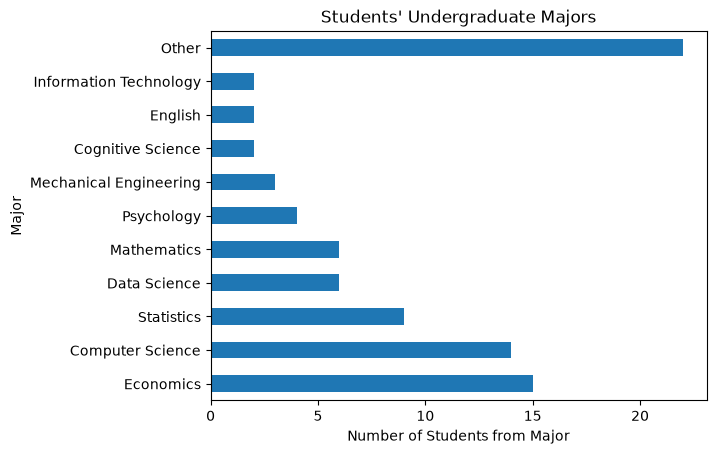

In [15]:
import matplotlib as mpl
major_counts_head = (major_counts.head(10))
major_counts_other = major_counts.iloc[10:].sum()
major_counts_group = pd.concat([major_counts_head, pd.Series({'Other': major_counts_other})])
major_counts_group.plot(kind = 'barh')
mpl.pyplot.xlabel('Number of Students from Major')
mpl.pyplot.ylabel('Major')
mpl.pyplot.title("Students' Undergraduate Majors")


All majors with only one response were marked as 'Other', so the majority of students have unique majors. Economics, Computer Science, and Statistics are the top three most popular majors among MSDS Class of 2027 students. 

Text(0.5, 1.0, "Students' Type of Phone")

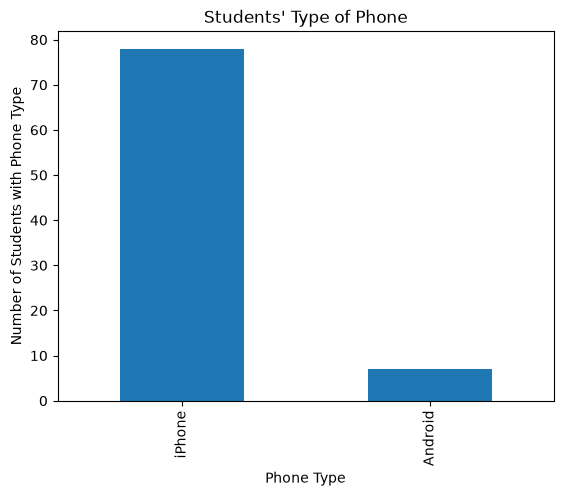

In [16]:
phone_counts.plot(kind = 'bar')
mpl.pyplot.xlabel('Phone Type')
mpl.pyplot.ylabel('Number of Students with Phone Type')
mpl.pyplot.title("Students' Type of Phone")

The vast majority of students have iPhones.

Text(0.5, 1.0, "Time Since Students' Undergraduate Degrees Conferred")

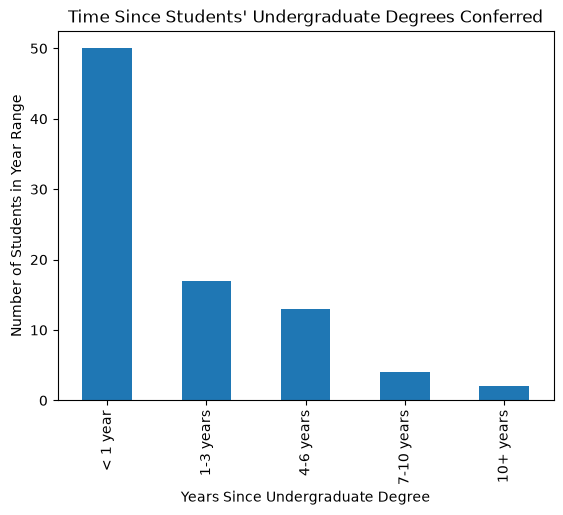

In [17]:
year_counts.plot(kind = 'bar')
mpl.pyplot.xlabel('Years Since Undergraduate Degree')
mpl.pyplot.ylabel('Number of Students in Year Range')
mpl.pyplot.title("Time Since Students' Undergraduate Degrees Conferred")

Most students received their undergraduate degrees less than 1 year ago, and as the years increase the number of students decreases.

Text(0.5, 1.0, 'Hours of Sleep per Night by Students')

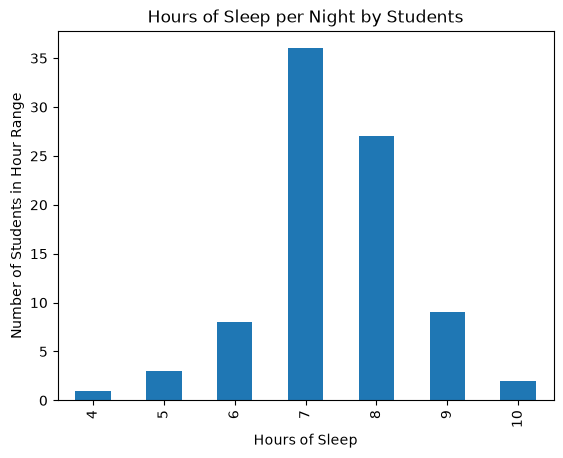

In [18]:
sleep_counts_sorted = sleep_counts.sort_index()
sleep_counts_sorted.plot(kind = 'bar')
mpl.pyplot.xlabel('Hours of Sleep')
mpl.pyplot.ylabel('Number of Students in Hour Range')
mpl.pyplot.title("Hours of Sleep per Night by Students")

The distribution of hours of sleep among students spikes at 7-8 hours, and leads me to believe a greater sample size would lead to an approximately normal distribution.

Text(0.5, 1.0, "Students' Level of Git Experience")

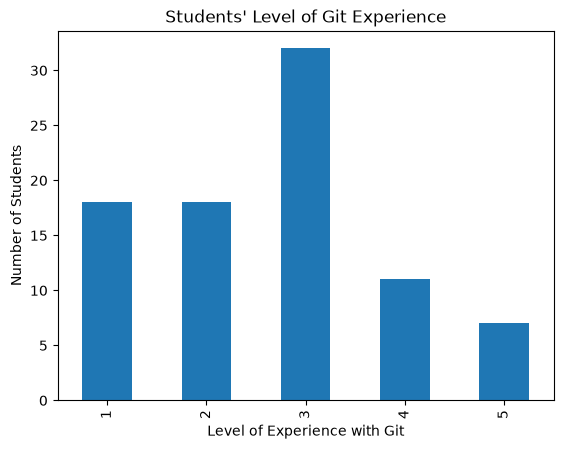

In [19]:
git_counts_sorted = git_counts.sort_index()
git_counts_sorted.plot(kind = 'bar')
mpl.pyplot.xlabel('Level of Experience with Git')
mpl.pyplot.ylabel('Number of Students')
mpl.pyplot.title("Students' Level of Git Experience")

Most students have a medium level of experience, although on average students have slightly less than a medium level of experience. 

Text(0.5, 1.0, "Students' Level of Python Experience")

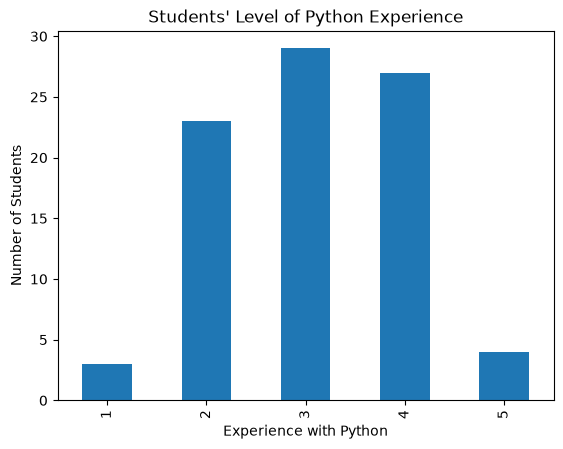

In [20]:
python_counts_sorted = python_counts.sort_index()
python_counts_sorted.plot(kind = 'bar')
mpl.pyplot.xlabel('Experience with Python')
mpl.pyplot.ylabel('Number of Students')
mpl.pyplot.title("Students' Level of Python Experience")

Students have much more experience with Python than with Git on average.

Text(0.5, 1.0, 'Students with SQL Experience')

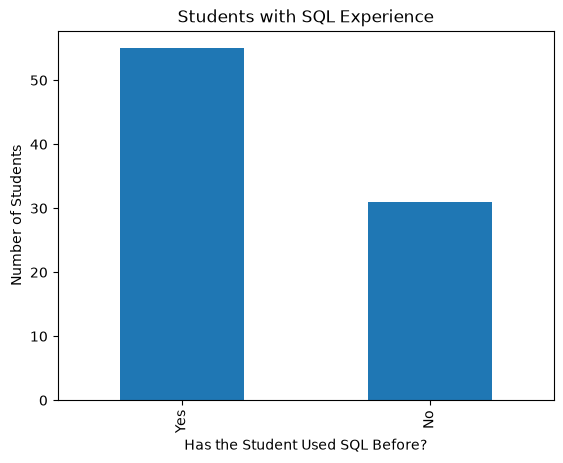

In [21]:
SQL_counts.plot(kind = 'bar')
mpl.pyplot.xlabel('Has the Student Used SQL Before?')
mpl.pyplot.ylabel('Number of Students')
mpl.pyplot.title("Students with SQL Experience")

The majority of students have used SQL, although there are a decent amount with no SQL experience.

Text(0.5, 1.0, "Students' Favorite Sports to Watch")

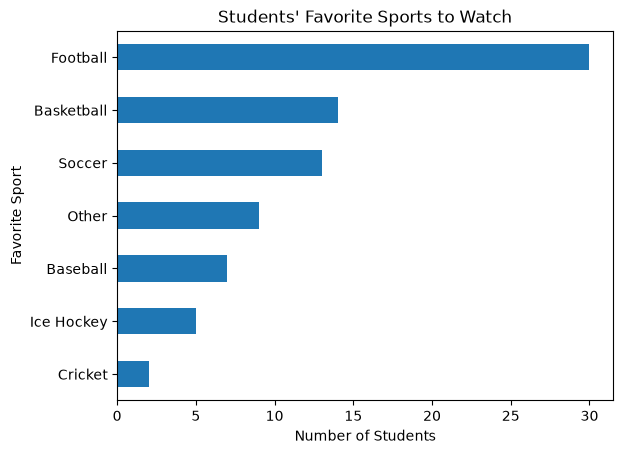

In [22]:
sport_counts_head = (sport_counts.head(6))
sport_counts_other = sport_counts.iloc[6:].sum()
sport_counts_group = pd.concat([sport_counts_head, pd.Series({'Other': sport_counts_other})])
sport_counts_group_sorted = sport_counts_group.sort_values()
sport_counts_group_sorted.plot(kind = 'barh')

mpl.pyplot.ylabel('Favorite Sport')
mpl.pyplot.xlabel('Number of Students')
mpl.pyplot.title("Students' Favorite Sports to Watch")

Most students prefer football, although there are a wide variety of different sports they prefer.

Text(0.5, 1.0, 'Favorite Temperatures of Students')

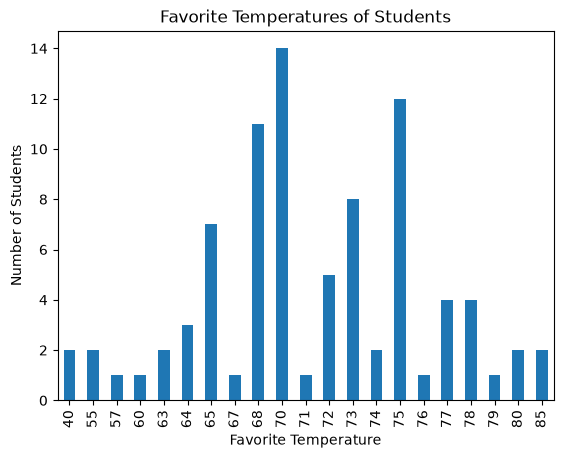

In [23]:
temp_counts_sorted = temp_counts.sort_index()
temp_counts_sorted.plot(kind = 'bar')
mpl.pyplot.xlabel('Favorite Temperature')
mpl.pyplot.ylabel('Number of Students')
mpl.pyplot.title("Favorite Temperatures of Students")

Students prefer a wide variety of temperatures, although the majority prefer a high 60s - low 70s range.

Text(0.5, 1.0, 'Number of States Visited by Students')

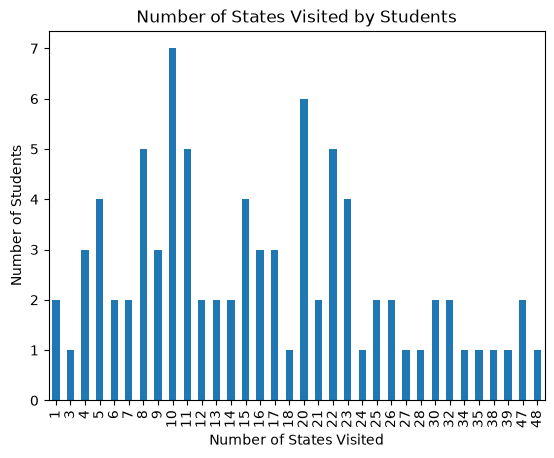

In [24]:
state_counts_sorted = state_counts.sort_index()
state_counts_sorted.plot(kind = 'bar')
mpl.pyplot.xlabel('Number of States Visited')
mpl.pyplot.ylabel('Number of Students')
mpl.pyplot.title("Number of States Visited by Students")

Students have visited a wide variety of states, highlighting the unique background and perspective each brings. 

Text(0.5, 1.0, 'Favorite Seasons of Students')

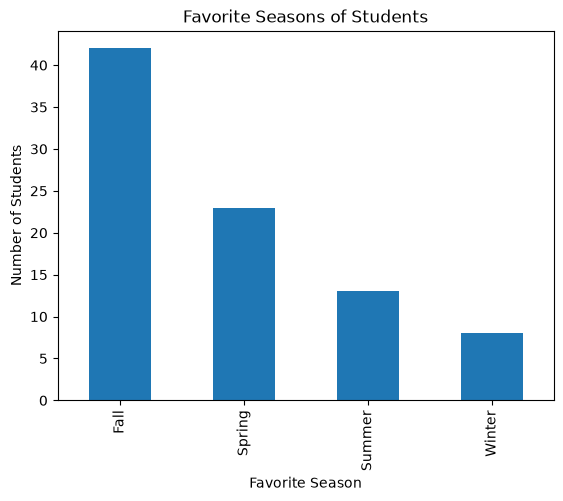

In [25]:
season_counts.plot(kind = 'bar')
mpl.pyplot.xlabel('Favorite Season')
mpl.pyplot.ylabel('Number of Students')
mpl.pyplot.title("Favorite Seasons of Students")

Most students prefer the more moderate seasons.

Part 5

Text(0.5, 1.0, 'Correlation Between Hours of Sleep and Favorite Temperature')

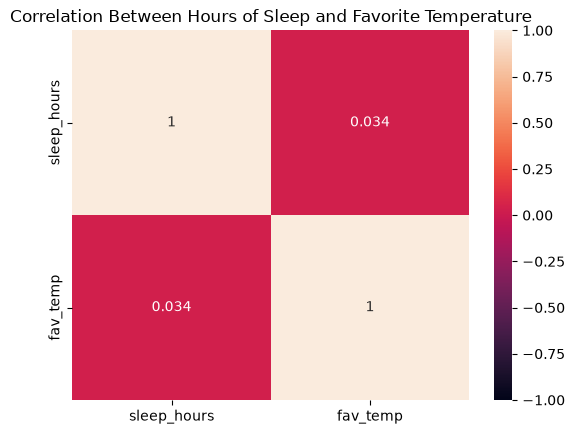

In [26]:
sleep_corr = df[['sleep_hours', 'fav_temp']].corr()
#print(sleep_corr)
import seaborn
#help(seaborn.heatmap)
seaborn.heatmap(sleep_corr, annot = True, vmin = -1, vmax = 1)
mpl.pyplot.title('Correlation Between Hours of Sleep and Favorite Temperature')

1. I chose these two variables because I believed there might have been a correlation between hours of sleep and favorite temperature. For example, if someone has trouble sleeping in warmer weather, I hypothesized they would prefer colder temperatures and fewer hours of sleep.  
2. The correlation coefficient of 0.034 show that there is almost no correlation between favorite temperature and hours of sleep.
3. I do not see evidence of any sort of relationship. 

Text(0, 0.5, 'Preferred Outdoor Temperature')

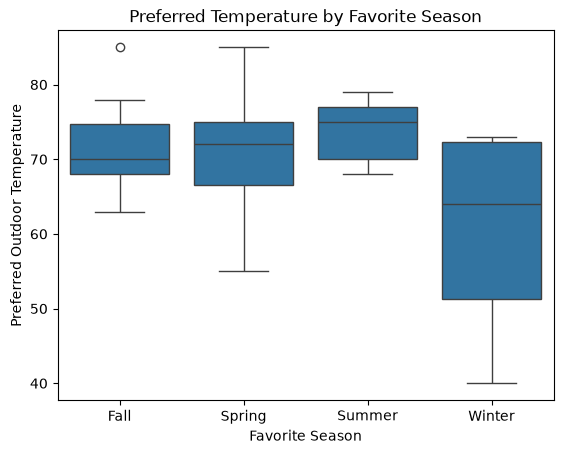

In [27]:
seaborn.boxplot(data = df, x = 'fav_season', y = 'fav_temp')
mpl.pyplot.title('Preferred Temperature by Favorite Season')
mpl.pyplot.xlabel('Favorite Season')
mpl.pyplot.ylabel('Preferred Outdoor Temperature')

1. I believed that these two variables would have significant overlap. Temperature and season are correlated, and this should lead students' preferences to be similarly correlated.
2. The boxplot shows that students with fall, spring, and summer as their favorite season all have similar temperature preferences, as the medians are all overlapping in the 70 to 75 degree range. Those with winter as their favorite season are much lower, with a median of about 65 degrees. This result could have been skewed by the two responses of 40 degrees, as evidenced by the large whisker.
3. I see evidence of an interesting relationship between winter enjoyers and those that prefer the rest of the seasons. I had originally hypothesized that those with summer as their favorite season would have a much higher temperature then they ended up having.   

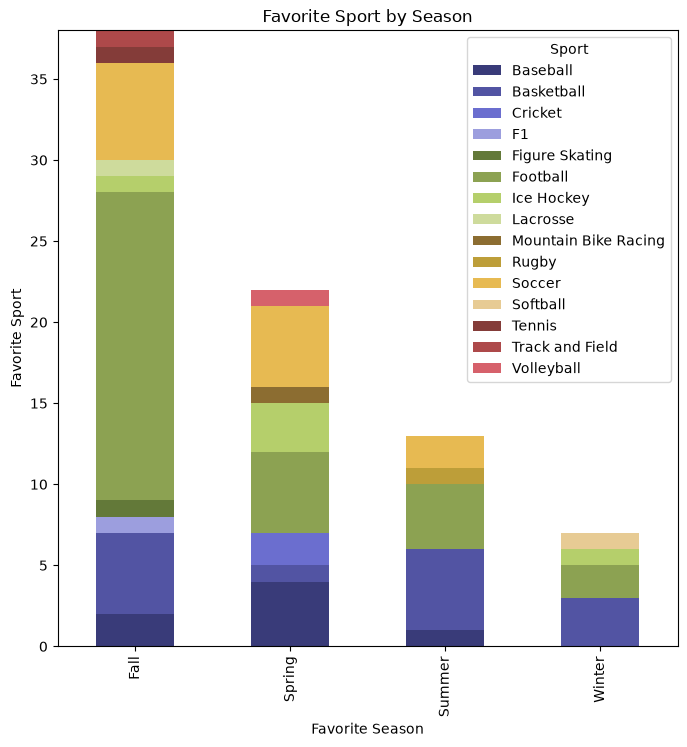

In [28]:
season_counts
sport_counts_other
crosstab = pd.crosstab(df['fav_season'], df['fav_sport'])
crosstab.plot(kind = 'bar', stacked = True, figsize = (8, 8),
              color = seaborn.color_palette("tab20b", 15))
mpl.pyplot.xlabel('Favorite Season')
mpl.pyplot.ylabel('Favorite Sport')
mpl.pyplot.title("Favorite Sport by Season")
mpl.pyplot.legend(title = 'Sport')

1. I originally hypothesized that people would enjoy sports taking place during their favorite season, or vice versa.
2. Many sports take place across multiple seasons, but the stacked bar chart shows that sports that more people prefer seasons when their favorite sport is on. Many football fans enjoy fall and baseball and soccer fans enjoy spring, when their sports are being played. One notable exception to this hypothesis is basketball fans enjoying summer, when there is much less professional activity taking place during this season.
3. There could be an interesting relationship between these two variables. It is possible the relationship does not exist between every season and sport, or with sports whose professional leagues are played across multiple seasons.

Part 6

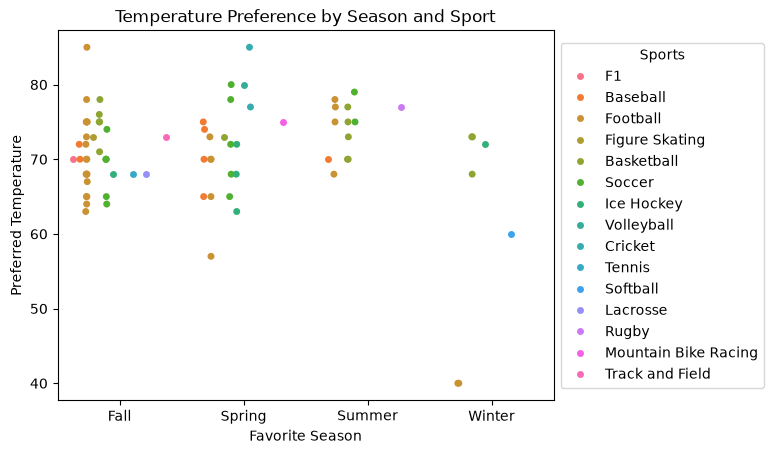

In [46]:
#help(seaborn.stripplot)
from matplotlib import pyplot as plt
seaborn.stripplot(data = df, x = 'fav_season', y = 'fav_temp', hue = 'fav_sport',
                  jitter = True, dodge = True)
plt.xlabel('Favorite Season')
plt.ylabel('Preferred Temperature')
plt.title('Temperature Preference by Season and Sport')
plt.legend(title = 'Sports',
           bbox_to_anchor = (1, .5),
           loc = 'center left'
           )
#help(plt.legend)

By adding favorite sport to the plot of favorite season and temperature, we are better able to visualize the connection between sport and season. We can see that many of the same sport preferences are close together, with a few outliers in football.    

Part 7

I would like to predict whether or not a student has experience with SQL. This could be accomplished using a logistic regression, with the predictors proficiency in Git, proficiency in Python, and undergraduate major. Git and Python proficiency are both relevant to using SQL because all three work in tandem to analyze data and produce results. I believe undergraduate major also plays a role in SQL knowledge, as those who come from more technical backgrounds might have more experience using SQL to manage data. The rest of the variables in the survey likely would be insignificant, as they have no effect on technical knowledge and use of SQL. Before fitting the model, the data would have to be cleaned up, and any unhelpful responses to the survey would be removed. More responses may also be required, and expanding the scale of Git and Python knowledge from 1 to 5 to 1 to 10 could be a possiblity. Additionally, the undergraduate major responses may have to be consolidated even further for the predictor to be significant.